In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load final dataset
df = pd.read_excel("weather_pm_ghg_final_clean.xlsx")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Station", "Date"])

# Create output folder
os.makedirs("eda_figures", exist_ok=True)

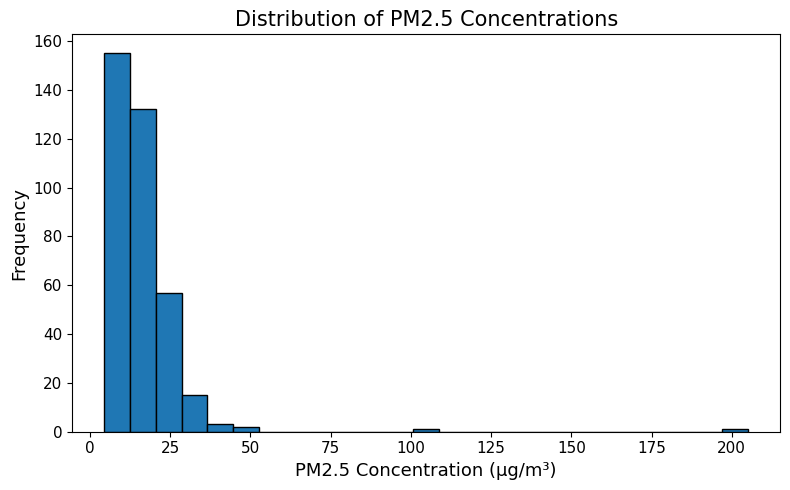

In [2]:
plt.figure(figsize=(8, 5))
plt.hist(df["PM2.5"], bins=25, edgecolor="black")
plt.xlabel("PM2.5 Concentration (µg/m³)", fontsize=13)
plt.ylabel("Frequency", fontsize=13)
plt.title("Distribution of PM2.5 Concentrations", fontsize=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig("eda_figures/pm25_histogram.png", dpi=300)
plt.show()

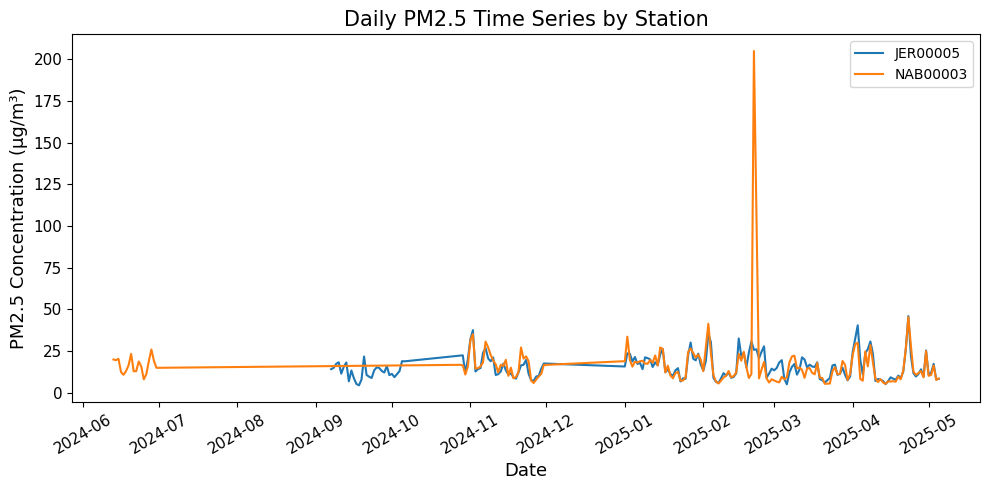

In [3]:
plt.figure(figsize=(10, 5))

for station in df["Station"].unique():
    temp = df[df["Station"] == station]
    plt.plot(temp["Date"], temp["PM2.5"], label=station)

plt.xlabel("Date", fontsize=13)
plt.ylabel("PM2.5 Concentration (µg/m³)", fontsize=13)
plt.title("Daily PM2.5 Time Series by Station", fontsize=15)
plt.legend()
plt.xticks(fontsize=11, rotation=30)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig("eda_figures/pm25_time_series.png", dpi=300)
plt.show()

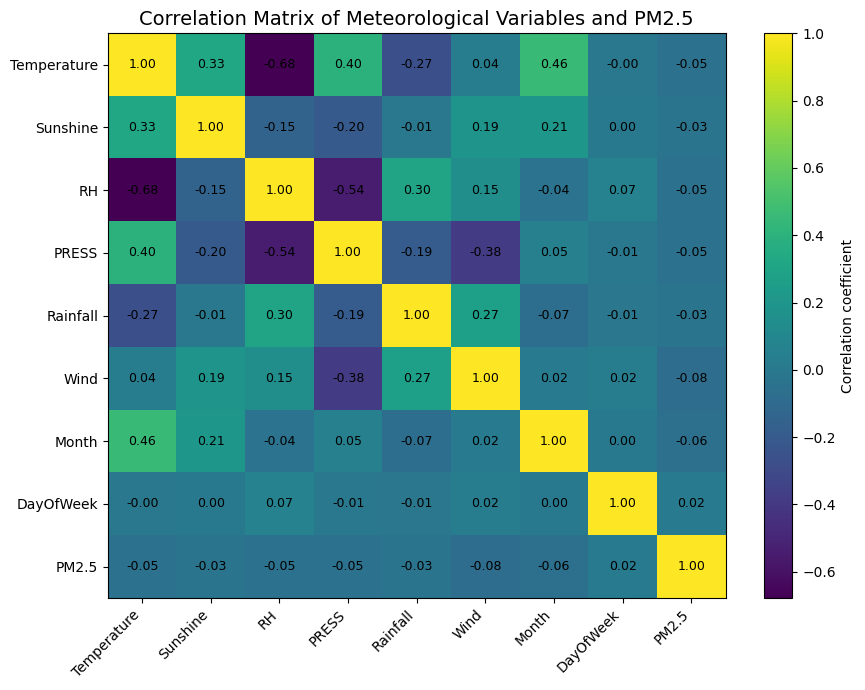

In [4]:
corr_cols = [
    "Temperature", "Sunshine", "RH", "PRESS",
    "Rainfall", "Wind", "Month", "DayOfWeek", "PM2.5"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation coefficient")

plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right", fontsize=10)
plt.yticks(range(len(corr_cols)), corr_cols, fontsize=10)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=9)

plt.title("Correlation Matrix of Meteorological Variables and PM2.5", fontsize=14)
plt.tight_layout()
plt.savefig("eda_figures/correlation_heatmap.png", dpi=300)
plt.show()

/var/folders/94/m24mcb0j0750z3mg0b61fn640000gn/T/ipykernel_10555/3475059481.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=months, showmeans=True)


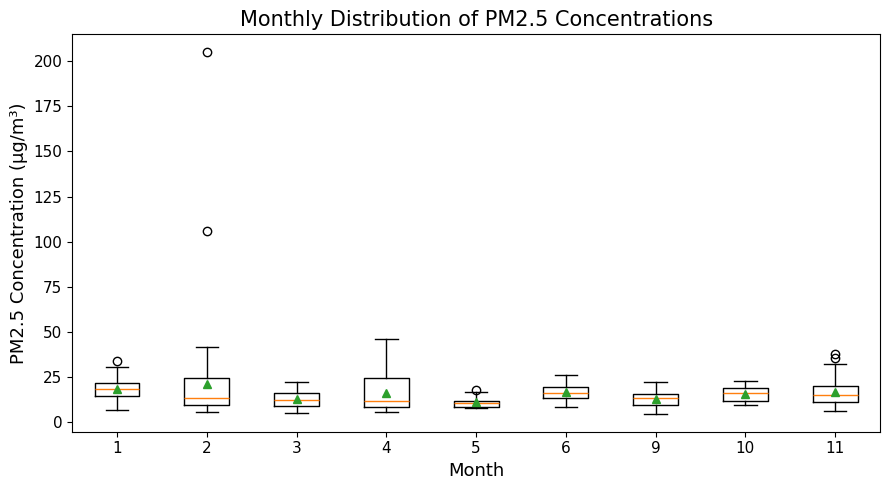

In [5]:
months = sorted(df["Month"].unique())
data = [df[df["Month"] == m]["PM2.5"] for m in months]

plt.figure(figsize=(9, 5))
plt.boxplot(data, labels=months, showmeans=True)
plt.xlabel("Month", fontsize=13)
plt.ylabel("PM2.5 Concentration (µg/m³)", fontsize=13)
plt.title("Monthly Distribution of PM2.5 Concentrations", fontsize=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig("eda_figures/pm25_monthly_boxplot.png", dpi=300)
plt.show()

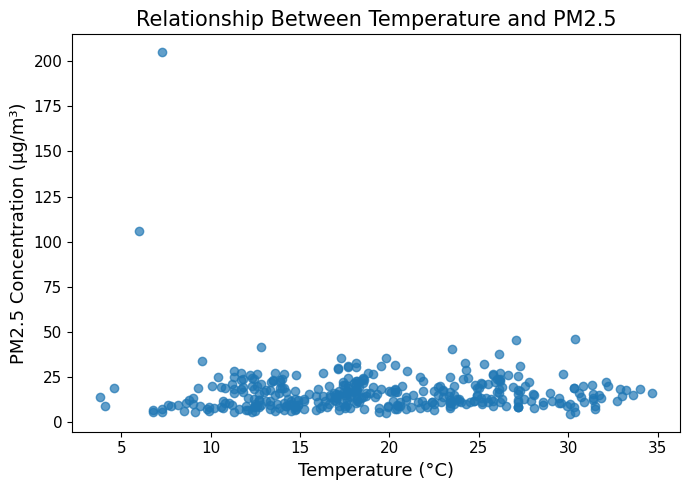

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Temperature"], df["PM2.5"], alpha=0.7)
plt.xlabel("Temperature (°C)", fontsize=13)
plt.ylabel("PM2.5 Concentration (µg/m³)", fontsize=13)
plt.title("Relationship Between Temperature and PM2.5", fontsize=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig("eda_figures/pm25_vs_temperature.png", dpi=300)
plt.show()

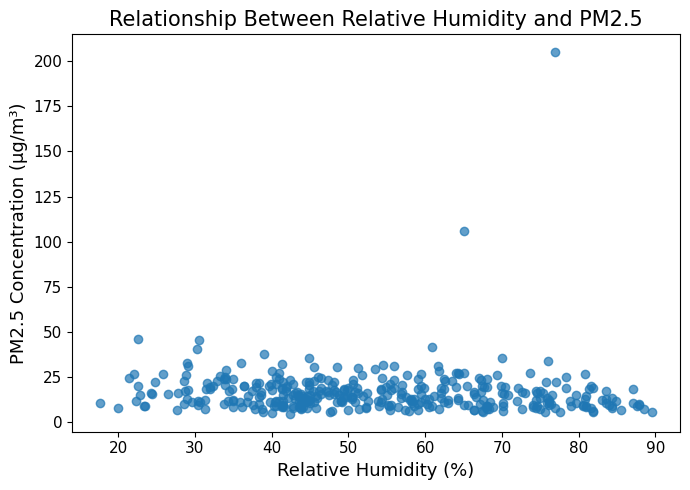

In [7]:
plt.figure(figsize=(7, 5))
plt.scatter(df["RH"], df["PM2.5"], alpha=0.7)
plt.xlabel("Relative Humidity (%)", fontsize=13)
plt.ylabel("PM2.5 Concentration (µg/m³)", fontsize=13)
plt.title("Relationship Between Relative Humidity and PM2.5", fontsize=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig("eda_figures/pm25_vs_rh.png", dpi=300)
plt.show()

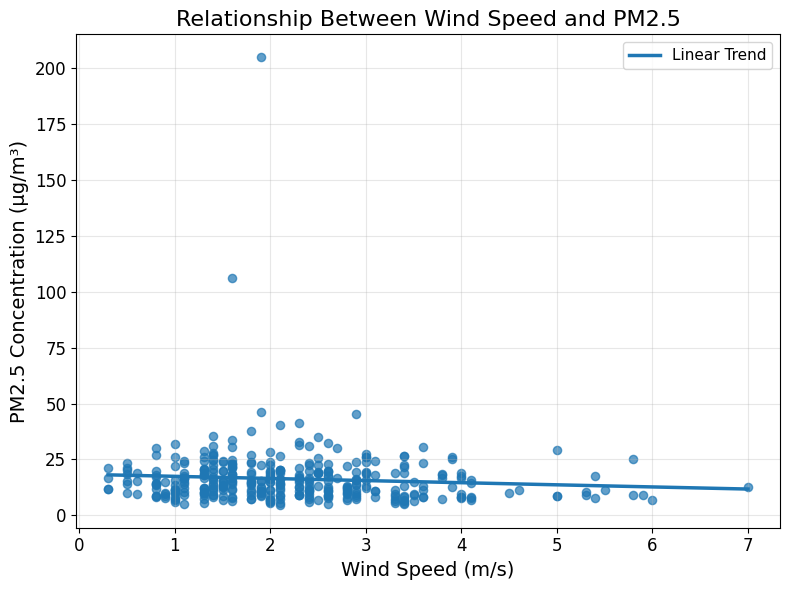

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load dataset
df = pd.read_excel("weather_pm_ghg_final_clean.xlsx")

# Create output directory
os.makedirs("eda_figures", exist_ok=True)

# Sort by wind speed for a smooth trend line
df = df.sort_values("Wind")

# Fit a linear trend
z = np.polyfit(df["Wind"], df["PM2.5"], 1)
p = np.poly1d(z)

# Create figure
plt.figure(figsize=(8, 6))

# Scatter points
plt.scatter(
    df["Wind"],
    df["PM2.5"],
    alpha=0.7,
    s=35
)

# Trend line
plt.plot(
    df["Wind"],
    p(df["Wind"]),
    linewidth=2.5,
    label="Linear Trend"
)

# Labels
plt.xlabel("Wind Speed (m/s)", fontsize=14)
plt.ylabel("PM2.5 Concentration (µg/m³)", fontsize=14)
plt.title("Relationship Between Wind Speed and PM2.5", fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=11)

plt.grid(alpha=0.3)
plt.tight_layout()

# Save
plt.savefig(
    "eda_figures/pm25_vs_wind_speed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

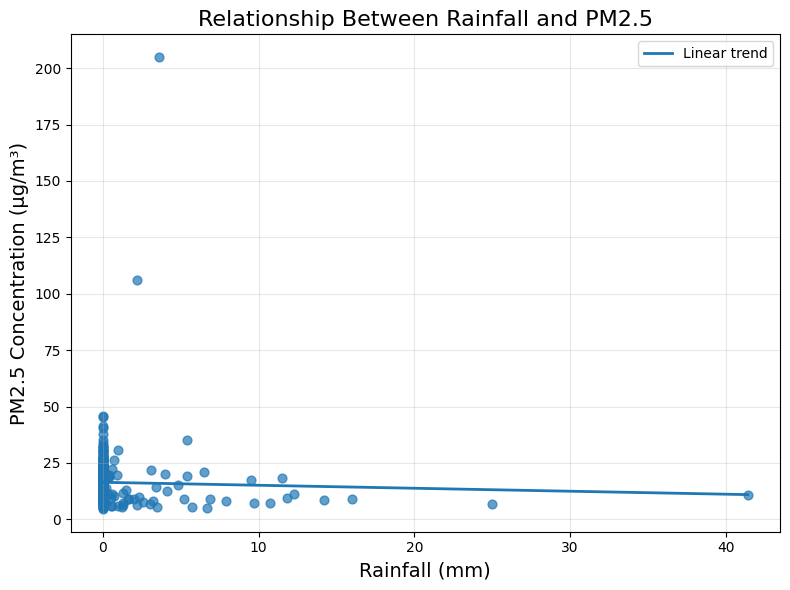

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load data
df = pd.read_excel("weather_pm_ghg_final_clean.xlsx")

# Create output folder
os.makedirs("eda_figures", exist_ok=True)

# Sort by rainfall
df = df.sort_values("Rainfall")

# Fit linear trend
z = np.polyfit(df["Rainfall"], df["PM2.5"], 1)
p = np.poly1d(z)

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Rainfall"],
    df["PM2.5"],
    alpha=0.7,
    s=40
)

plt.plot(
    df["Rainfall"],
    p(df["Rainfall"]),
    linewidth=2,
    label="Linear trend"
)

plt.xlabel("Rainfall (mm)", fontsize=14)
plt.ylabel("PM2.5 Concentration (µg/m³)", fontsize=14)
plt.title("Relationship Between Rainfall and PM2.5", fontsize=16)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "eda_figures/pm25_vs_rainfall.png",
    dpi=300
)

plt.show()

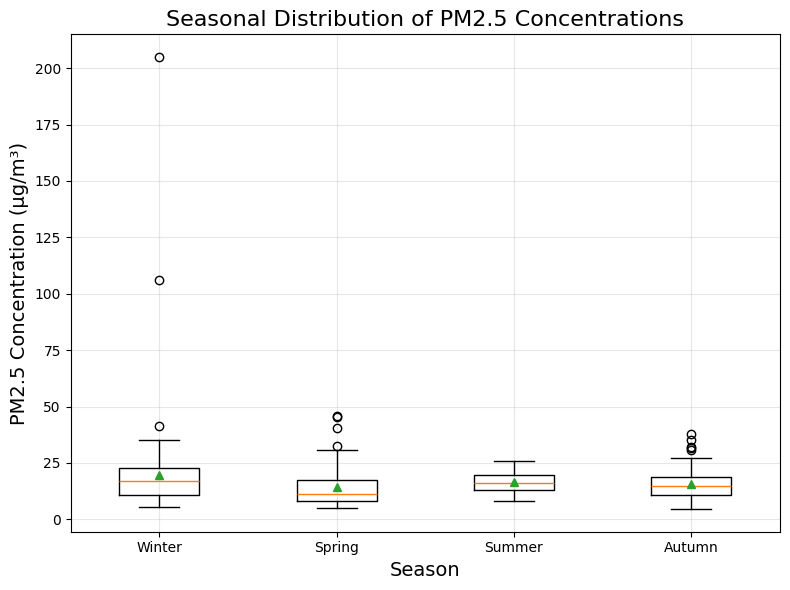

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load data
df = pd.read_excel("weather_pm_ghg_final_clean.xlsx")

# Assign seasons
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

# Order seasons
season_order = ["Winter", "Spring", "Summer", "Autumn"]

data = [
    df[df["Season"] == s]["PM2.5"]
    for s in season_order
]

# Plot
plt.figure(figsize=(8, 6))

plt.boxplot(
    data,
    tick_labels=season_order,
    showmeans=True
)

plt.xlabel("Season", fontsize=14)
plt.ylabel("PM2.5 Concentration (µg/m³)", fontsize=14)
plt.title("Seasonal Distribution of PM2.5 Concentrations", fontsize=16)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "eda_figures/pm25_seasonal_boxplot.png",
    dpi=300
)

plt.show()

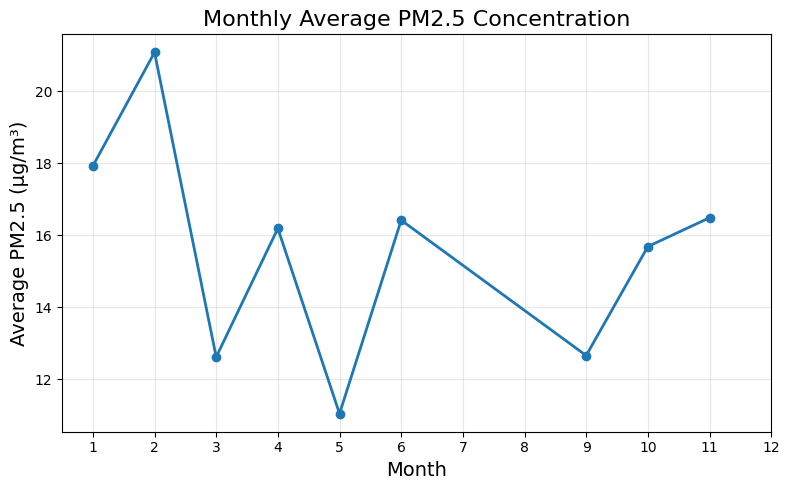

In [11]:
monthly = df.groupby("Month")["PM2.5"].mean()

plt.figure(figsize=(8,5))
plt.plot(monthly.index, monthly.values, marker="o", linewidth=2)

plt.xlabel("Month", fontsize=14)
plt.ylabel("Average PM2.5 (µg/m³)", fontsize=14)
plt.title("Monthly Average PM2.5 Concentration", fontsize=16)

plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "eda_figures/monthly_average_pm25.png",
    dpi=300
)

plt.show()